## Load and clean dataset from Zinser et al. 2009
- https://doi.org/10.1371/journal.pone.0005135

In [1]:
# suppress warnings
import warnings
warnings.simplefilter('ignore')
# import installed packages
import pandas as pd
import numpy as np
import xarray as xr
from statsmodels.tsa.seasonal import STL

In [2]:
# add full path to modules, replace with your own
full_path = '/Users/Kathy/Library/CloudStorage/OneDrive-UW/Desktop/UW/seaflow/decomposition_project/scripts'
# import functions from custom modules
import sys
sys.path.insert(0, full_path)
from simulation_tools import *
from diel_tools import *
from fig_tools import *
from tsd_functions import *
from rate_functions import *
from model_simulations import *

### Calculating hourly Qc from FCM and combining with measurements data
Returns single dataframe with all necessary data for analysis: `pro_data`

In [3]:
# read in flow cytometry data
culture_data=pd.read_csv('../simulation_data/zinser_figure2a.csv')
psd_data=pd.read_csv('../simulation_data/zinser_psd.csv')

#### reformat to calculate hourly average Qc ####
# get experimental time from culture dataset
X = list(culture_data['exper time'])
# get size classes from psd data columns
Y = list(psd_data.columns[1:].astype(float))
# get particle size distrubition data from dataframe
Z = psd_data.iloc[:,1:].T.to_numpy()

# make new dataframe with particle size distribution data and reset the index
df = pd.DataFrame(data=Z, columns=X, index=Y).reset_index()
# rename column to size_bin
df.rename(columns={'index':'size_bin'},inplace=True)
# reformat data from wide to long
df_long=pd.melt(df, id_vars=['size_bin'], var_name='hour', value_name='abundance')
# calculate sum of each size bin using size and abundance
df_long['Qc_sum'] = df_long['size_bin'] * df_long['abundance']
# filter out size classes with no abundance
df_long = df_long[df_long.abundance > 0]

# group by cruise and date to get n and summed qc by the hour
df_group = df_long.groupby(['hour']).sum().reset_index()
# get mean Qc per hour and convert Qc from fg -> pg
df_group['Qc_hour'] = (df_group['Qc_sum']/df_group['abundance'])
# calculate variance per hour (fg -> pg)
df_var = df_long.merge(df_group[['hour', 'Qc_hour']])
# convert sizes from pg to fg
df_var['size_bin'] = df_var['size_bin'] 
# calculate squared difference of sizes and mean 
df_var['Qc_diff'] = (df_var['size_bin'] - df_var['Qc_hour'])**2
# get sum of all squared differences and abundances
df_var_hour = df_var.groupby(['hour']).sum().reset_index()
# calculate hourly (sample) variance
df_var_hour['Qc_var'] = df_var_hour['Qc_diff'] / (df_var['abundance'] - 1)
# merge with mean
df_group = df_group.merge(df_var_hour[['hour', 'Qc_var']])
# subset just the columns we care about
pro_data = df_group[['hour','Qc_hour', 'Qc_var']]

### Make heat map of flow cytometry data

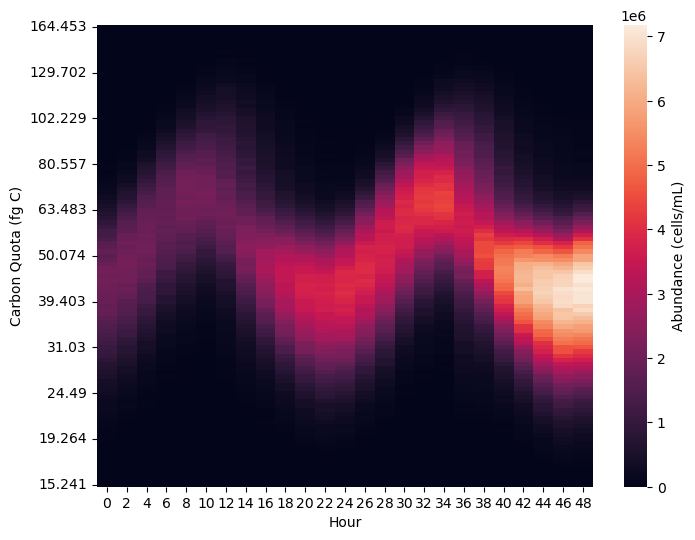

In [4]:
from matplotlib.ticker import StrMethodFormatter
# plot heat map of psd data
X = list(culture_data['exper time'])
Y = list(np.round(psd_data.columns[1:].astype(float),3))
# psd_data without the first col
Z = psd_data.iloc[:,1:].T.to_numpy()

# make new dataframe and plt
df = pd.DataFrame(data=Z, columns=X, index=Y)
df.sort_index(level=1, inplace=True,ascending=False)
# draw heat map
fig,axs=plt.subplots(figsize=(8,6))
# plot
s=sns.heatmap(df, square=False, yticklabels=11, cbar_kws={'label': 'Abundance (cells/mL)'})
s.set(xlabel='Hour', ylabel='Carbon Quota (fg C)')
# Round ytick labels
plt.rcParams.update({'font.size':15})
plt.show()

#### Add in PAR and measurements data

In [5]:
# get PAR data
ds = xr.open_dataset('../simulation_data/zinser_processed.nc',
                    decode_times=False)
pro_data['par']=ds.PAR.values
# fix par rounding error (should be night at hour 12, 22, 36, and 46)
pro_data.loc[pro_data['hour'].isin([12,36]), 'par']=0
# adjust for sunrise

# get c-fixation and loss data
gt = xr.open_dataset('../simulation_data/zinser_ground_truth.nc',
                    decode_times=False)
# get carbon fixation for all rows in pg
pro_data['GPP']=gt.carbonfix.values#/1000
pro_data['GPP_sd'] = gt.carbonfix_sd.values#/1000
# get carbon loss for all rows except last in pg
pro_data.loc[0:23,'carbonloss']=gt.carbonloss.values#/1000
pro_data.loc[0:23,'carbonloss_sd']=gt.carbonloss_sd.values#/1000
# add net c-fiszation for all rows
pro_data['NPP'] = pro_data['GPP']-pro_data['carbonloss']
pro_data['NPP_sd'] = np.sqrt(pro_data['GPP_sd']**2 + pro_data['carbonloss_sd']**2)

### Plot measured rates dataset

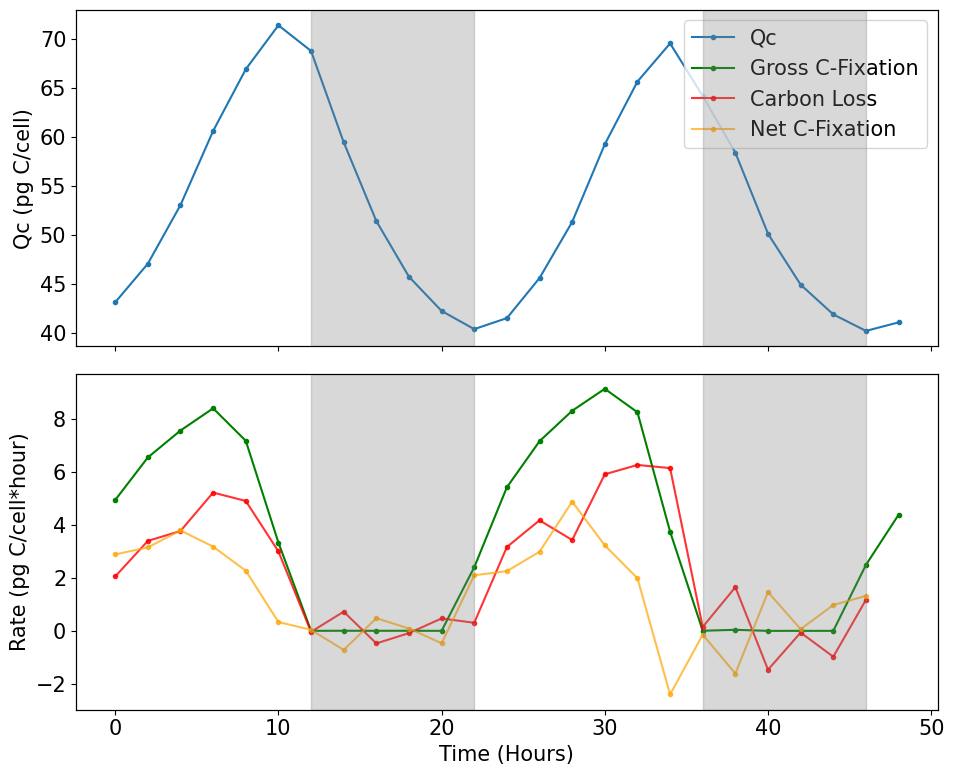

In [6]:
#### Plot to check if simulation successful ####
plot_simulated_rates(pro_data)

### Carbon Loss vs Gross Fixation

In [7]:
from scipy.integrate import cumtrapz

# split dataset into 2 days
day1 = pro_data[0:11]
day2 = pro_data[11:23]
day3 = pro_data[23:25]
# calculate each day's integrated GPP
day1_intGPP = np.trapz(day1['GPP'],day1['hour']) 
day2_intGPP = np.trapz(day2['GPP'],day2['hour']) 
day3_intGPP = np.trapz(day3['GPP'],day3['hour']) 
# calculate mean int GPP (add bit from day 3 to day 1)
mean_intGPP = np.mean([day1_intGPP+day3_intGPP, day2_intGPP])
print(f'Mean daily integrated GPP: {np.round(mean_intGPP, 5)}')

### now do NPP
# calculate each day's integrated NPP
day1_intNPP = np.trapz(day1['carbonloss'],day1['hour']) 
day2_intNPP = np.trapz(day2['carbonloss'],day2['hour']) 
day3_intNPP = np.trapz(day3['carbonloss'],day3['hour']) 
# calculate mean int NPP (add bit from day 3 to day 1)
mean_intNPP = np.mean([day1_intNPP, day2_intNPP])
print(f'Mean daily integrated carbonloss: {np.round(mean_intNPP, 5)}')

Mean daily integrated GPP: 82.34359
Mean daily integrated carbonloss: 50.786


### Run data through STL model

In [8]:
data=pro_data
col='Qc_hour'
period=12
robust=True

# get data to run in model
train=data[col]
# Run multiplicative STL model
stl_model = STL(np.log(train), period=period, robust=robust)
# fit to data
stl_fit = stl_model.fit()

# add components to datasets
data['trend']=np.exp(stl_fit.trend.values.reshape(-1,1))
data['diel']=np.exp(stl_fit.seasonal.values.reshape(-1,1))
data['resid']=np.exp(stl_fit.resid.values.reshape(-1,1))

# plot growth and productivity
data['hourly_growth']=exp_growth(data, 'diel',2).shift(-1)
# calculate hourly productivity
prod_conv=np.mean(data['Qc_hour'])
data['productivity']=data['hourly_growth']*prod_conv
# fix productivity
data.loc[data['productivity']<0 ,'productivity']=0

## Run bootstrapping

In [10]:
mbb_df, mbb_data=run_bootstrapping(data, runs=1000)

# perform bagging on bootstrapped data
stl_bagged=bagging_results(mbb_data)

## Figure 1

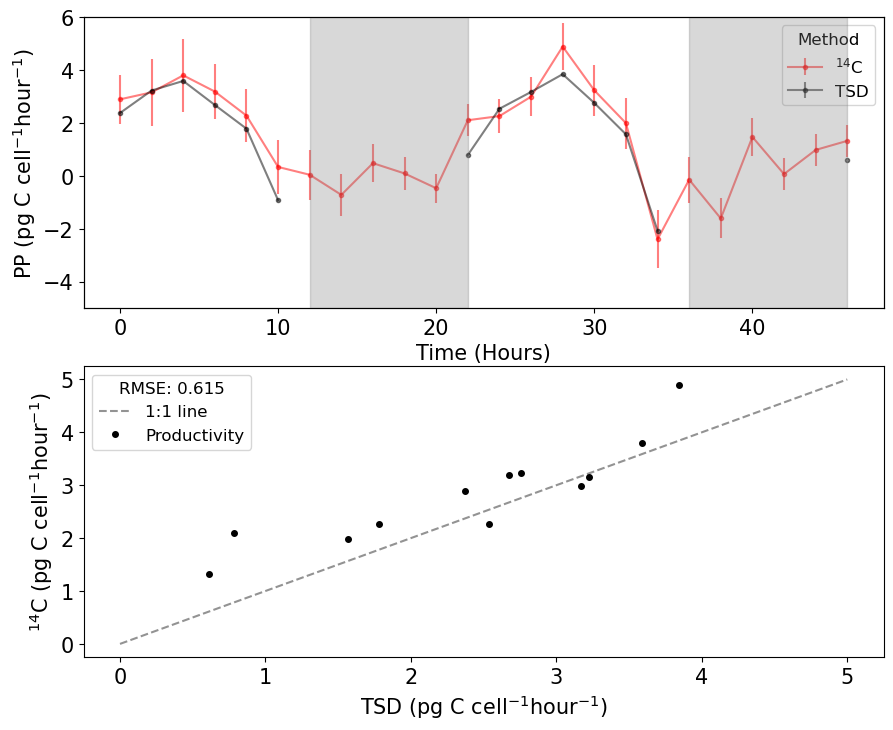

In [11]:
# get days only
days_only = stl_bagged.loc[(stl_bagged['par']>0)&(stl_bagged['productivity_mean']>0)]
# only plot day light hours productivity
days_only_na = stl_bagged.copy()
days_only_na.loc[days_only_na['par'] == 0, 'productivity_mean'] = np.nan

# calculate error metrics
pred=days_only.productivity_mean[:-1]
actual=days_only.NPP[:-1]
# get rmse
rmse, smpae, mase=error_metrics(pred, actual)

# make plot with bagged results
fig,axs=plt.subplots(figsize=(10,8), nrows=2)
# plot original and bagged results with standard deviation
axs[0].errorbar(pro_data['hour'], pro_data['NPP'], yerr = pro_data['NPP_sd'], label='$\mathregular{^{14}C}$', marker='.', c='red',alpha=0.5)
axs[0].errorbar(days_only_na.index, days_only_na.productivity_mean, yerr = days_only_na['productivity_std'], 
                label='TSD', marker='.', c='k', alpha=0.5)
# adjust ylims
axs[0].set_ylim(-5, 6)

# plot day and night
twinax=axs[0].twinx()
plot_night_day(twinax, stl_bagged.reset_index(), ylims=(4, 75))#, ylims=(0.04, 0.075))
axs[0].set_xlabel('Time (Hours)')
axs[0].set_ylabel('PP (pg C $\mathregular{cell^{-1} hour^{-1}}$)')
axs[0].legend(title='Method', fontsize=12, title_fontsize=12)
# axs[0].set_title(f'100x Bootstrapped {model} Decomposition')

# plot comparison of day productivity values
x=[0,5]
axs[1].plot(x,x,label='1:1 line',c='gray',marker='', alpha=0.85, linestyle='--')
axs[1].plot(days_only['productivity_mean'],days_only['NPP'],marker='.',linestyle='',label='Productivity',
           markersize=8,c='k')
# make axis labels
axs[1].set_xlabel('TSD (pg C $\mathregular{cell^{-1} hour^{-1}}$)')
axs[1].set_ylabel('$\mathregular{^{14}C}$ (pg C $\mathregular{cell^{-1} hour^{-1}}$)')
axs[1].legend(title=f'RMSE: {np.round(rmse,5)}', title_fontsize=12, fontsize=12)
# clean up
plt.tight_layout()
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.2)